Width: 25545
Height: 14916
Bounds: BoundingBox(left=0.0, bottom=14916.0, right=25545.0, top=0.0)
Raw Min: 0.0
Raw Max: 1480.0


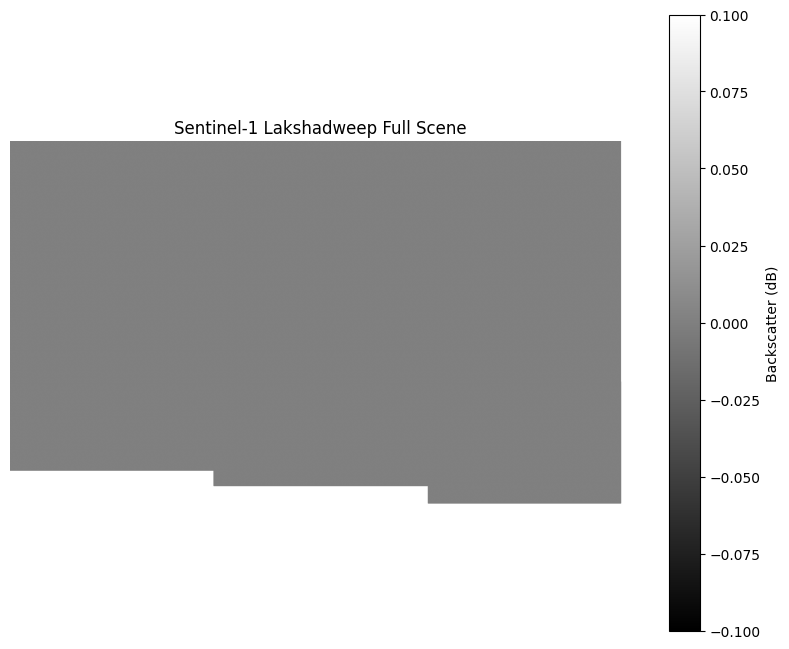

In [9]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.enums import Resampling

# Path to your Sentinel-1 GRD TIFF
file_path = "lak2.tiff"

with rasterio.open(file_path) as src:
    print("Width:", src.width)
    print("Height:", src.height)
    print("Bounds:", src.bounds)

    # Read full image but downscale ONLY for visualization
    scale_factor = 6   # adjust between 4–8 if needed

    img = src.read(
        1,
        out_shape=(
            1,
            src.height // scale_factor,
            src.width // scale_factor
        ),
        resampling=Resampling.average
    )

# Convert to float32 to reduce memory
img = img.astype(np.float32)

print("Raw Min:", np.nanmin(img))
print("Raw Max:", np.nanmax(img))

# Mask invalid values
img[img <= 0] = np.nan

# Convert to dB ONLY if values are not already in dB
if np.nanmax(img) > 1:
    # Already in dB (likely)
    img_db = img
else:
    # Convert to dB
    img_db = 10 * np.log10(img)

# Clip for good contrast (important for ocean scenes)
img_db = np.clip(img_db, -25, 0)

plt.figure(figsize=(10, 8))
plt.imshow(img_db, cmap='gray')
plt.colorbar(label="Backscatter (dB)")
plt.title("Sentinel-1 Lakshadweep Full Scene")
plt.axis("off")
plt.show()